# VA vs CLIP-ViT partial RSA and two-model variance partitioning

This cleaned notebook removes the GIST model, other model comparisons, and all EEG analyses. It focuses only on the relationship between the **valence–arousal (VA) RDM** and the **CLIP-ViT image-embedding RDM** in three fMRI ROI partitions:

1. **VA-only**: voxels significant for VA but outside the CLIP-ViT mask  
2. **Overlap**: voxels shared by VA and CLIP-ViT masks  
3. **CLIP-only**: voxels in the CLIP-ViT mask but outside the VA mask

The CLIP-ViT mask is built from:

`tmap_clipvit_p001_fisherz_fdr001_th0.nii.gz`

with the actual mask threshold:

`CLIP mask = tmap > 9.5`


In [1]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from sklearn.metrics import pairwise_distances
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr, pearsonr, ttest_1samp, zscore, rankdata
from statsmodels.stats.multitest import fdrcorrection


## 1. Paths and analysis settings

Edit these paths if your folder structure is different.

In [5]:
# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
PATH_ALLSUB = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\allsub_avg.npy"

# VA searchlight mask. Keep your current VA thresholded map/mask here.
# Voxels > 0 are treated as the VA mask.
PATH_VA_MASK = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\final_results\tmap_beh60_p05_v2.nii.gz"

# CLIP-ViT t-map used to define the CLIP mask.
# The actual mask will be: CLIP t-map > CLIP_T_THRESHOLD.
PATH_CLIP_TMAP = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\tmap_clipvit_p001_fisherz_fdr001_th0.nii.gz"
CLIP_T_THRESHOLD = 9.5

# Model RDMs
PATH_VA_RDM = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\RDM\rdm_behavioral.csv"
PATH_CLIP_RDM = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\RDM\rdm_clipvit.csv"

OUT_DIR = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\partial_variance_VA_clipvit_t95"
os.makedirs(OUT_DIR, exist_ok=True)

print("Output directory:", OUT_DIR)


Output directory: N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\partial_variance_VA_clipvit_t95


## 2. Helper functions

In [6]:
def upper_tri(M):
    """Return the upper-triangular vector of a square RDM."""
    iu = np.triu_indices_from(M, k=1)
    return M[iu]


def minmax01(M):
    """Min-max normalize an RDM to [0, 1]."""
    M = np.asarray(M, dtype=float)
    return (M - np.nanmin(M)) / (np.nanmax(M) - np.nanmin(M))


def compute_rdm_in_mask(brain_data, mask):
    """
    Compute one fMRI neural RDM per subject within a binary ROI mask.

    brain_data shape should be: (n_subjects, n_stimuli, X, Y, Z)
    mask shape should be: (X, Y, Z)
    """
    n_subj, n_stim = brain_data.shape[:2]
    flat_mask = mask.ravel()

    if flat_mask.sum() == 0:
        raise ValueError("The ROI mask has 0 voxels. Check mask thresholding or image alignment.")

    X = brain_data.reshape(n_subj, n_stim, -1)
    rdms = np.zeros((n_subj, n_stim, n_stim), dtype=float)

    for s in range(n_subj):
        Xs = np.nan_to_num(X[s][:, flat_mask])
        rdms[s] = pairwise_distances(Xs, metric='correlation')

    return rdms


def _r2(X, y):
    """OLS R² after z-scoring predictors and response."""
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    X = np.nan_to_num(zscore(X, axis=0, ddof=1))
    y = np.nan_to_num(zscore(y, ddof=1))

    model = LinearRegression().fit(X, y)
    return model.score(X, y)


def variance_partition_2model(y, predictors):
    """
    Two-model variance partitioning.

    Model: brain RDM vector ~ predictor 1 + predictor 2

    Components:
    - unique predictor 1
    - unique predictor 2
    - shared predictor 1/predictor 2
    - full R²
    """
    assert len(predictors) == 2
    (n1, x1), (n2, x2) = list(predictors.items())

    r1 = _r2(x1, y)
    r2 = _r2(x2, y)
    r12 = _r2(np.column_stack([x1, x2]), y)

    u1 = r12 - r2
    u2 = r12 - r1
    shared = r1 + r2 - r12

    return {
        'R2_full': r12,
        f'R2_{n1}': r1,
        f'R2_{n2}': r2,
        f'unique_{n1}': u1,
        f'unique_{n2}': u2,
        f'shared_{n1}_{n2}': shared,
    }


def variance_partition_2model_per_subject(fmri_rdms, model_rdms_2):
    mv = {k: upper_tri(v) for k, v in model_rdms_2.items()}
    rows = []

    for s in range(fmri_rdms.shape[0]):
        y = upper_tri(fmri_rdms[s])
        row = variance_partition_2model(y, mv)
        row['subject'] = s + 1
        rows.append(row)

    return pd.DataFrame(rows).set_index('subject')


def partial_spearman(y, x, covariate):
    """Spearman partial correlation: corr(y, x | covariate)."""
    yr = rankdata(y)
    xr = rankdata(x)
    cr = rankdata(covariate)

    design = np.column_stack([np.ones(len(cr)), cr])

    by, *_ = np.linalg.lstsq(design, yr, rcond=None)
    bx, *_ = np.linalg.lstsq(design, xr, rcond=None)

    y_res = yr - design @ by
    x_res = xr - design @ bx

    r, _ = pearsonr(y_res, x_res)
    return r


def partial_rsa_2model_per_subject(fmri_rdms, model_rdms_2):
    names = list(model_rdms_2.keys())
    assert names == ['VA', 'CLIP'] or names == ['CLIP', 'VA']

    mv = {k: upper_tri(v) for k, v in model_rdms_2.items()}
    rows = []

    for s in range(fmri_rdms.shape[0]):
        y = upper_tri(fmri_rdms[s])
        r_va_zero, _ = spearmanr(y, mv['VA'])
        r_clip_zero, _ = spearmanr(y, mv['CLIP'])
        r_va_partial = partial_spearman(y, mv['VA'], mv['CLIP'])
        r_clip_partial = partial_spearman(y, mv['CLIP'], mv['VA'])

        rows.append({
            'subject': s + 1,
            'VA_zeroorder': r_va_zero,
            'CLIP_zeroorder': r_clip_zero,
            'VA_partial_control_CLIP': r_va_partial,
            'CLIP_partial_control_VA': r_clip_partial,
        })

    return pd.DataFrame(rows).set_index('subject')


def group_stats(df, cols):
    """One-sample greater-than-zero t-tests with FDR correction."""
    rows = []
    for c in cols:
        vals = df[c].values.astype(float)
        t, p = ttest_1samp(vals, 0.0, alternative='greater')
        rows.append({
            'component': c,
            'mean': np.nanmean(vals),
            'sem': np.nanstd(vals, ddof=1) / np.sqrt(np.sum(~np.isnan(vals))),
            't': t,
            'p_uncorr': p,
        })

    stats = pd.DataFrame(rows)
    rejected, p_fdr = fdrcorrection(stats['p_uncorr'].values, alpha=0.05)
    stats['p_fdr'] = p_fdr
    stats['sig'] = [
        '***' if p < 0.001 else
        '**' if p < 0.01 else
        '*' if p < 0.05 else
        'n.s.'
        for p in p_fdr
    ]
    return stats


## 3. Load fMRI data and define VA/CLIP masks

In [18]:
# ---------------------------------------------------------------------
# Load fMRI data
# ---------------------------------------------------------------------
allsub = np.load(PATH_ALLSUB, allow_pickle=True)
print("allsub shape:", allsub.shape)

# ---------------------------------------------------------------------
# Load masks/t-map
# ---------------------------------------------------------------------
va_mask_img = nib.load(PATH_VA_MASK)
clip_tmap_img = nib.load(PATH_CLIP_TMAP)

va_map = va_mask_img.get_fdata()
clip_tmap = clip_tmap_img.get_fdata()

# VA mask keeps the current binary/thresholded VA map definition.
va_mask = va_map > 0

# CLIP mask uses the requested actual threshold.
clip_mask = clip_tmap > CLIP_T_THRESHOLD

print("VA mask voxels:", int(va_mask.sum()))
print(f"CLIP mask voxels (t > {CLIP_T_THRESHOLD}):", int(clip_mask.sum()))

# ---------------------------------------------------------------------
# Shape checks and reshape brain data
# ---------------------------------------------------------------------
mask_shape = va_mask.shape
if clip_mask.shape != mask_shape:
    raise ValueError(f"VA mask shape {mask_shape} and CLIP mask shape {clip_mask.shape} do not match.")

# Accept either (subjects, 60, X, Y, Z) or (subjects, 60, voxels).
if allsub.ndim == 5:
    brain_data = allsub
elif allsub.ndim == 3:
    expected_voxels = int(np.prod(mask_shape))
    if allsub.shape[2] != expected_voxels:
        raise ValueError(
            f"allsub has {allsub.shape[2]} voxels, but mask has {expected_voxels}. "
            "Check that allsub and masks are in the same space/resolution."
        )
    brain_data = allsub.reshape(allsub.shape[0], allsub.shape[1], *mask_shape)
else:
    raise ValueError("allsub must have shape (subjects, stimuli, X, Y, Z) or (subjects, stimuli, voxels).")

print("brain_data shape:", brain_data.shape)

# ---------------------------------------------------------------------
# Define the three ROI partitions
# ---------------------------------------------------------------------
overlap_mask = va_mask & clip_mask
va_only_mask = va_mask & ~clip_mask
clip_only_mask = clip_mask & ~va_mask

roi_masks = {
    'VA-only': va_only_mask,
    'Overlap': overlap_mask,
    'CLIP-only': clip_only_mask,
}

for name, mask in roi_masks.items():
    print(f"{name:10s} voxels: {int(mask.sum())}")


allsub shape: (20, 60, 153594)
VA mask voxels: 1038
CLIP mask voxels (t > 9.5): 2625
brain_data shape: (20, 60, 53, 63, 46)
VA-only    voxels: 467
Overlap    voxels: 571
CLIP-only  voxels: 2054


In [9]:
print("VA mask voxels  :", int(va_mask.sum()))
print("CLIP mask voxels:", int(clip_mask.sum()))

overlap_mask = va_mask & clip_mask
print("Overlap voxels  :", int(overlap_mask.sum()))

VA mask voxels  : 1038
CLIP mask voxels: 2625
Overlap voxels  : 571


## 4. Load VA and CLIP-ViT model RDMs

In [13]:
# ---------------------------------------------------------------------
# Load model RDMs
# ---------------------------------------------------------------------
def load_square_rdm_csv(path, name="RDM"):
    """
    Robustly load an RDM CSV as a square numeric matrix.

    Why this is needed:
    - Some RDM CSVs are saved WITH an index column.
    - Some RDM CSVs are saved WITHOUT an index column.
    - If we always use index_col=0, a no-index 60x60 CSV becomes 60x59.
    """
    # First try the common case: CSV saved with an index column.
    df_idx = pd.read_csv(path, index_col=0)
    mat_idx = df_idx.apply(pd.to_numeric, errors="coerce").values

    if mat_idx.ndim == 2 and mat_idx.shape[0] == mat_idx.shape[1]:
        print(f"{name}: loaded with index_col=0 -> {mat_idx.shape}")
        return mat_idx

    # If not square, try reading the whole file with no index column.
    df = pd.read_csv(path)

    # Remove accidental unnamed index columns only when present.
    unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    if unnamed_cols:
        df_drop = df.drop(columns=unnamed_cols)
        mat_drop = df_drop.apply(pd.to_numeric, errors="coerce").values
        if mat_drop.ndim == 2 and mat_drop.shape[0] == mat_drop.shape[1]:
            print(f"{name}: loaded without index, dropped unnamed columns -> {mat_drop.shape}")
            return mat_drop

    mat = df.apply(pd.to_numeric, errors="coerce").values
    if mat.ndim == 2 and mat.shape[0] == mat.shape[1]:
        print(f"{name}: loaded without index_col -> {mat.shape}")
        return mat

    # Last-resort handling for headerless CSVs.
    mat_headerless = pd.read_csv(path, header=None).apply(pd.to_numeric, errors="coerce").values
    if mat_headerless.ndim == 2 and mat_headerless.shape[0] == mat_headerless.shape[1]:
        print(f"{name}: loaded as headerless CSV -> {mat_headerless.shape}")
        return mat_headerless

    raise ValueError(
        f"Could not load {name} as a square RDM from {path}. "
        f"Shapes tried: index_col=0 {mat_idx.shape}, no index {mat.shape}, headerless {mat_headerless.shape}."
    )


rdm_beh = load_square_rdm_csv(PATH_VA_RDM, name="VA RDM")
rdm_clip = load_square_rdm_csv(PATH_CLIP_RDM, name="CLIP RDM")

va_rdm = minmax01(rdm_beh)
clip_rdm = minmax01(rdm_clip)

print("VA RDM shape:", va_rdm.shape)
print("CLIP RDM shape:", clip_rdm.shape)

if va_rdm.shape != clip_rdm.shape:
    raise ValueError(f"VA RDM shape {va_rdm.shape} and CLIP RDM shape {clip_rdm.shape} do not match.")

model_rdms_2 = {
    'VA': va_rdm,
    'CLIP': clip_rdm,
}

r_model, p_model = spearmanr(upper_tri(va_rdm), upper_tri(clip_rdm))
print(f"VA–CLIP RDM Spearman correlation: r = {r_model:.4f}, p = {p_model:.3e}")



VA RDM: loaded with index_col=0 -> (60, 60)
CLIP RDM: loaded without index_col -> (60, 60)
VA RDM shape: (60, 60)
CLIP RDM shape: (60, 60)
VA–CLIP RDM Spearman correlation: r = 0.2904, p = 9.853e-36


## 5. Compute fMRI RDMs in VA-only, overlap, and CLIP-only ROIs

In [14]:
roi_rdms = {}
for roi_name, mask in roi_masks.items():
    if mask.sum() == 0:
        print(f"Skipping {roi_name}: 0 voxels")
        continue
    roi_rdms[roi_name] = compute_rdm_in_mask(brain_data, mask)
    print(f"{roi_name:10s} RDMs shape: {roi_rdms[roi_name].shape}")


VA-only    RDMs shape: (20, 60, 60)
Overlap    RDMs shape: (20, 60, 60)
CLIP-only  RDMs shape: (20, 60, 60)


## 6. Two-model partial RSA and variance partitioning

In [15]:
partial_results = {}
vp_results = {}
all_partial_stats = []
all_vp_stats = []

for roi_name, rdms in roi_rdms.items():
    print("\n" + "=" * 80)
    print(f"ROI: {roi_name}")
    print("=" * 80)

    # Partial RSA
    df_partial = partial_rsa_2model_per_subject(rdms, model_rdms_2)
    partial_results[roi_name] = df_partial
    df_partial.to_csv(os.path.join(OUT_DIR, f"partial_rsa_{roi_name}_per_subject.csv"))

    partial_cols = ['VA_zeroorder', 'CLIP_zeroorder', 'VA_partial_control_CLIP', 'CLIP_partial_control_VA']
    stats_partial = group_stats(df_partial, partial_cols)
    stats_partial.insert(0, 'ROI', roi_name)
    all_partial_stats.append(stats_partial)
    stats_partial.to_csv(os.path.join(OUT_DIR, f"partial_rsa_{roi_name}_stats.csv"), index=False)

    print("\nPartial RSA stats:")
    print(stats_partial.round(5).to_string(index=False))

    # Two-model variance partitioning
    df_vp = variance_partition_2model_per_subject(rdms, model_rdms_2)
    vp_results[roi_name] = df_vp
    df_vp.to_csv(os.path.join(OUT_DIR, f"variance_partition_{roi_name}_per_subject.csv"))

    vp_cols = ['unique_VA', 'shared_VA_CLIP', 'unique_CLIP', 'R2_full']
    stats_vp = group_stats(df_vp, vp_cols)
    stats_vp.insert(0, 'ROI', roi_name)
    all_vp_stats.append(stats_vp)
    stats_vp.to_csv(os.path.join(OUT_DIR, f"variance_partition_{roi_name}_stats.csv"), index=False)

    print("\nVariance partitioning stats:")
    print(stats_vp.round(5).to_string(index=False))

# Save combined stats
all_partial_stats_df = pd.concat(all_partial_stats, ignore_index=True)
all_vp_stats_df = pd.concat(all_vp_stats, ignore_index=True)

all_partial_stats_df.to_csv(os.path.join(OUT_DIR, "partial_rsa_all_roi_stats.csv"), index=False)
all_vp_stats_df.to_csv(os.path.join(OUT_DIR, "variance_partition_all_roi_stats.csv"), index=False)

print("\nSaved combined stats:")
print(os.path.join(OUT_DIR, "partial_rsa_all_roi_stats.csv"))
print(os.path.join(OUT_DIR, "variance_partition_all_roi_stats.csv"))



ROI: VA-only

Partial RSA stats:
    ROI               component    mean     sem        t  p_uncorr   p_fdr  sig
VA-only            VA_zeroorder 0.06550 0.01310  5.00191   0.00004 0.00005  ***
VA-only          CLIP_zeroorder 0.21354 0.01287 16.59717   0.00000 0.00000  ***
VA-only VA_partial_control_CLIP 0.00369 0.01374  0.26876   0.39551 0.39551 n.s.
VA-only CLIP_partial_control_VA 0.20406 0.01317 15.49371   0.00000 0.00000  ***

Variance partitioning stats:
    ROI      component    mean     sem       t  p_uncorr   p_fdr  sig
VA-only      unique_VA 0.00283 0.00053 5.38352   0.00002 0.00002  ***
VA-only shared_VA_CLIP 0.00261 0.00156 1.66899   0.05576 0.05576 n.s.
VA-only    unique_CLIP 0.03898 0.00505 7.71348   0.00000 0.00000  ***
VA-only        R2_full 0.04442 0.00533 8.33024   0.00000 0.00000  ***

ROI: Overlap

Partial RSA stats:
    ROI               component    mean     sem        t  p_uncorr   p_fdr sig
Overlap            VA_zeroorder 0.11371 0.01560  7.28806   0.00000 0.0000

## 7. Plot two-model variance partitioning across ROIs

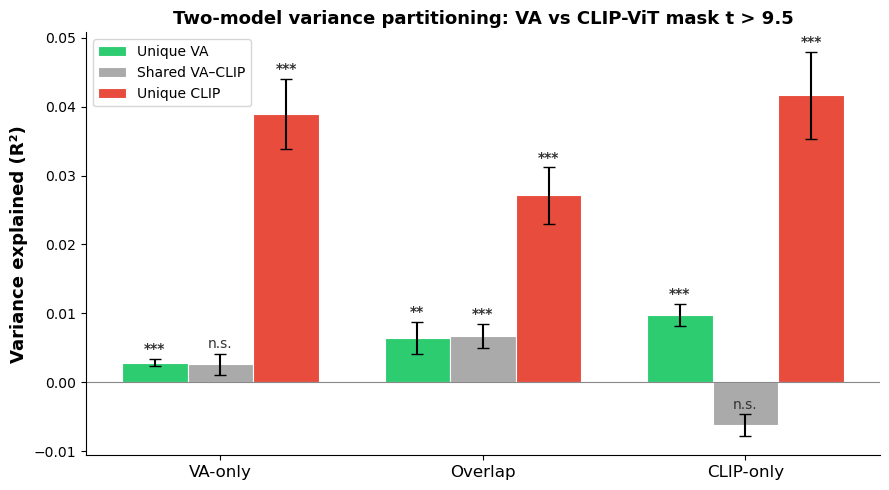

Saved figure:
N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\partial_variance_VA_clipvit_t95\variance_partition_VA_vs_CLIP_t9p5.png
N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\partial_variance_VA_clipvit_t95\variance_partition_VA_vs_CLIP_t9p5.pdf


In [ ]:
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

roi_order = [r for r in ['VA-only', 'Overlap', 'CLIP-only'] if r in vp_results]
components = ['unique_VA', 'shared_VA_CLIP', 'unique_CLIP']
labels = {
    'unique_VA': 'Unique VA',
    'shared_VA_CLIP': 'Shared VA–CLIP',
    'unique_CLIP': 'Unique CLIP',
}
colors = {
    'unique_VA': '#2ecc71',
    'shared_VA_CLIP': '#AAAAAA',
    'unique_CLIP': '#e74c3c',
}

# stats for labels
stats_plot = pd.concat([
    group_stats(vp_results[roi], components).assign(ROI=roi)
    for roi in roi_order
], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(roi_order))
width = 0.25

for i, comp in enumerate(components):
    means = [vp_results[roi][comp].mean() for roi in roi_order]
    sems = [vp_results[roi][comp].sem() for roi in roi_order]
    xpos = x + (i - 1) * width

    ax.bar(
        xpos,
        means,
        width,
        yerr=sems,
        capsize=4,
        color=colors[comp],
        edgecolor='white',
        linewidth=0.8,
        label=labels[comp],
    )

    for j, roi in enumerate(roi_order):
        row = stats_plot[(stats_plot['ROI'] == roi) & (stats_plot['component'] == comp)]
        if not row.empty:
            sig = row['sig'].values[0]
            y_pos = means[j] + sems[j] + 0.0004
            ax.text(
                xpos[j],
                y_pos,
                sig,
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold' if sig != 'n.s.' else 'normal',
                color='#333333',
            )

ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(roi_order, fontsize=12)
ax.set_ylabel('Variance explained (R²)', fontsize=13, fontweight='bold')
ax.set_title(f'Two-model variance partitioning: VA vs CLIP-ViT mask t > {CLIP_T_THRESHOLD}', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, framealpha=0.8)
plt.tight_layout()

# fig_png = os.path.join(OUT_DIR, f"variance_partition_VA_vs_CLIP_t{str(CLIP_T_THRESHOLD).replace('.', 'p')}.png")
# fig_pdf = os.path.join(OUT_DIR, f"variance_partition_VA_vs_CLIP_t{str(CLIP_T_THRESHOLD).replace('.', 'p')}.pdf")
# plt.savefig(fig_png, dpi=300, bbox_inches='tight')
# plt.savefig(fig_pdf, dpi=300, bbox_inches='tight')
# plt.show()

# print("Saved figure:")
# print(fig_png)
# print(fig_pdf)


In [32]:
# ============================================================
# Split ROI masks by hemisphere and run variance partitioning
# ============================================================

# Get MNI x-coordinate for every voxel
img_ref = nib.load(PATH_CLIP_TMAP)   # or any NIfTI with same shape/affine
affine = img_ref.affine
shape = img_ref.shape

ijk = np.indices(shape).reshape(3, -1).T
xyz = nib.affines.apply_affine(affine, ijk)
x_mni = xyz[:, 0].reshape(shape)

left_hemi_mask = x_mni < 0
right_hemi_mask = x_mni > 0

hemi_masks = {
    'Left': left_hemi_mask,
    'Right': right_hemi_mask
}

vp_results_hemi = {}

for hemi_name, hemi_mask in hemi_masks.items():

    vp_results_hemi[hemi_name] = {}

    for roi_name, roi_mask in roi_masks.items():

        roi_hemi_mask = roi_mask & hemi_mask

        print(f"{hemi_name} {roi_name}: {roi_hemi_mask.sum()} voxels")

        if roi_hemi_mask.sum() < 10:
            continue

        roi_rdms = compute_rdm_in_mask(
            brain_data,
            roi_hemi_mask
        )

        df_vp = variance_partition_2model_per_subject(
            roi_rdms,
            model_rdms_2
        )

        vp_results_hemi[hemi_name][roi_name] = df_vp

Left VA-only: 234 voxels
Left Overlap: 179 voxels
Left CLIP-only: 678 voxels
Right VA-only: 316 voxels
Right Overlap: 309 voxels
Right CLIP-only: 888 voxels


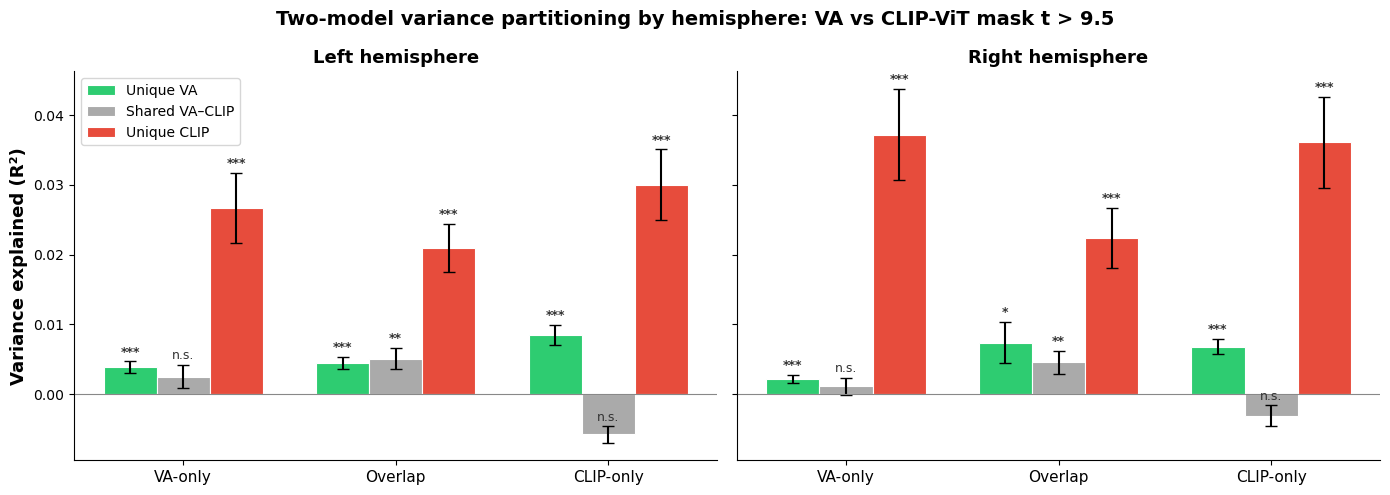

In [33]:
# ============================================================
# Plot variance partitioning by hemisphere
# ============================================================

def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

components = ['unique_VA', 'shared_VA_CLIP', 'unique_CLIP']

labels = {
    'unique_VA': 'Unique VA',
    'shared_VA_CLIP': 'Shared VA–CLIP',
    'unique_CLIP': 'Unique CLIP',
}

colors = {
    'unique_VA': '#2ecc71',
    'shared_VA_CLIP': '#AAAAAA',
    'unique_CLIP': '#e74c3c',
}

roi_order = ['VA-only', 'Overlap', 'CLIP-only']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, hemi_name in zip(axes, ['Left', 'Right']):

    hemi_results = vp_results_hemi[hemi_name]

    roi_order_hemi = [
        r for r in roi_order
        if r in hemi_results
    ]

    stats_plot = pd.concat([
        group_stats(hemi_results[roi], components).assign(ROI=roi)
        for roi in roi_order_hemi
    ], ignore_index=True)

    x = np.arange(len(roi_order_hemi))
    width = 0.25

    for i, comp in enumerate(components):

        means = [
            hemi_results[roi][comp].mean()
            for roi in roi_order_hemi
        ]

        sems = [
            hemi_results[roi][comp].sem()
            for roi in roi_order_hemi
        ]

        xpos = x + (i - 1) * width

        ax.bar(
            xpos,
            means,
            width,
            yerr=sems,
            capsize=4,
            color=colors[comp],
            edgecolor='white',
            linewidth=0.8,
            label=labels[comp] if hemi_name == 'Left' else None
        )

        for j, roi in enumerate(roi_order_hemi):

            row = stats_plot[
                (stats_plot['ROI'] == roi) &
                (stats_plot['component'] == comp)
            ]

            if not row.empty:
                sig = row['sig'].values[0]
                y_pos = means[j] + sems[j] + 0.0004

                ax.text(
                    xpos[j],
                    y_pos,
                    sig,
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    fontweight='bold' if sig != 'n.s.' else 'normal',
                    color='#333333'
                )

    ax.axhline(0, color='#888888', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_order_hemi, fontsize=11)
    ax.set_title(f'{hemi_name} hemisphere', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Variance explained (R²)', fontsize=13, fontweight='bold')

fig.suptitle(
    f'Two-model variance partitioning by hemisphere: VA vs CLIP-ViT mask t > {CLIP_T_THRESHOLD}',
    fontsize=14,
    fontweight='bold'
)

axes[0].legend(fontsize=10, framealpha=0.8)

plt.tight_layout()
plt.show()

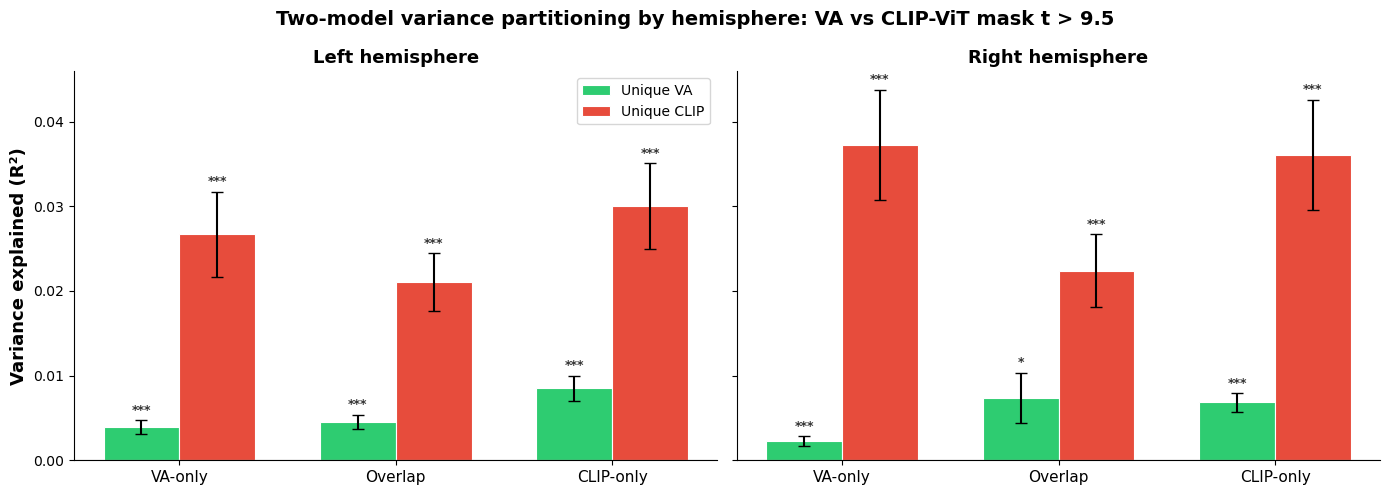

In [34]:
# ============================================================
# Plot variance partitioning by hemisphere
# ============================================================

def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

components = ['unique_VA',  'unique_CLIP']

labels = {
    'unique_VA': 'Unique VA',
    'unique_CLIP': 'Unique CLIP',
}

colors = {
    'unique_VA': '#2ecc71',
    'unique_CLIP': '#e74c3c',
}

roi_order = ['VA-only', 'Overlap', 'CLIP-only']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, hemi_name in zip(axes, ['Left', 'Right']):

    hemi_results = vp_results_hemi[hemi_name]

    roi_order_hemi = [
        r for r in roi_order
        if r in hemi_results
    ]

    stats_plot = pd.concat([
        group_stats(hemi_results[roi], components).assign(ROI=roi)
        for roi in roi_order_hemi
    ], ignore_index=True)

    x = np.arange(len(roi_order_hemi))
    width = 0.35

    for i, comp in enumerate(components):

        means = [
            hemi_results[roi][comp].mean()
            for roi in roi_order_hemi
        ]

        sems = [
            hemi_results[roi][comp].sem()
            for roi in roi_order_hemi
        ]

        xpos = x + (i - 0.5) * width
        
        ax.bar(
            xpos,
            means,
            width,
            yerr=sems,
            capsize=4,
            color=colors[comp],
            edgecolor='white',
            linewidth=0.8,
            label=labels[comp] if hemi_name == 'Left' else None
        )

        for j, roi in enumerate(roi_order_hemi):

            row = stats_plot[
                (stats_plot['ROI'] == roi) &
                (stats_plot['component'] == comp)
            ]

            if not row.empty:
                sig = row['sig'].values[0]
                y_pos = means[j] + sems[j] + 0.0004

                ax.text(
                    xpos[j],
                    y_pos,
                    sig,
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    fontweight='bold' if sig != 'n.s.' else 'normal',
                    color='#333333'
                )

    ax.axhline(0, color='#888888', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_order_hemi, fontsize=11)
    ax.set_title(f'{hemi_name} hemisphere', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Variance explained (R²)', fontsize=13, fontweight='bold')

fig.suptitle(
    f'Two-model variance partitioning by hemisphere: VA vs CLIP-ViT mask t > {CLIP_T_THRESHOLD}',
    fontsize=14,
    fontweight='bold'
)

axes[0].legend(fontsize=10, framealpha=0.8)

plt.tight_layout()
plt.show()

## 8. Save ROI masks used in the analysis

This saves the exact VA-only, overlap, and CLIP-only masks generated from the current VA mask and the CLIP-ViT t > 9.5 mask.

In [ ]:
for roi_name, mask in roi_masks.items():
    out_path = os.path.join(OUT_DIR, f"mask_{roi_name.replace('-', '_')}_VA_clip_t{str(CLIP_T_THRESHOLD).replace('.', 'p')}.nii.gz")
    out_img = nib.Nifti1Image(mask.astype(np.int16), affine=va_mask_img.affine, header=va_mask_img.header)
    out_img.to_filename(out_path)
    print(f"Saved {roi_name:10s}: {out_path} | voxels = {int(mask.sum())}")


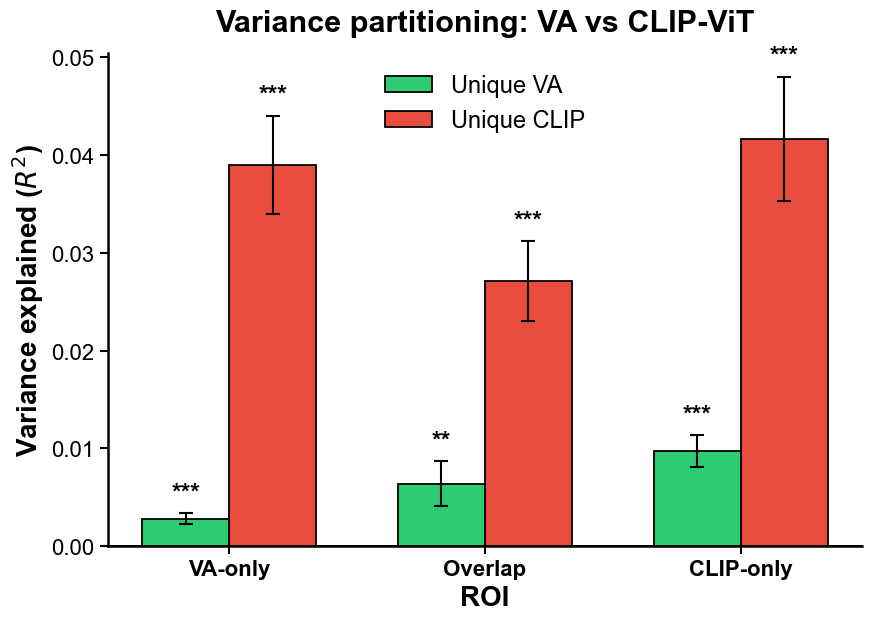

In [39]:
# ============================================================
# Publication-quality plot: larger fonts
# ============================================================

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 16,
    'axes.linewidth': 1.8,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

components = ['unique_VA', 'unique_CLIP']

labels = {
    'unique_VA': 'Unique VA',
    'unique_CLIP': 'Unique CLIP',
}

colors = {
    'unique_VA': '#2ecc71',
    'unique_CLIP': '#e74c3c',
}

roi_order = [r for r in ['VA-only', 'Overlap', 'CLIP-only'] if r in vp_results]

stats_plot = pd.concat([
    group_stats(vp_results[roi], components).assign(ROI=roi)
    for roi in roi_order
], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 6.5))

x = np.arange(len(roi_order))
width = 0.34

for comp in components:

    means = [vp_results[roi][comp].mean() for roi in roi_order]
    sems = [vp_results[roi][comp].sem() for roi in roi_order]

    xpos = x - width / 2 if comp == 'unique_VA' else x + width / 2

    ax.bar(
        xpos,
        means,
        width,
        yerr=sems,
        capsize=5,
        color=colors[comp],
        edgecolor='black',
        linewidth=1.3,
        error_kw={
            'elinewidth': 1.5,
            'capthick': 1.5,
            'ecolor': 'black'
        },
        label=labels[comp],
        zorder=3
    )

    for j, roi in enumerate(roi_order):

        row = stats_plot[
            (stats_plot['ROI'] == roi) &
            (stats_plot['component'] == comp)
        ]

        if not row.empty:
            sig = row['sig'].values[0]

            ax.text(
                xpos[j],
                means[j] + sems[j] + 0.0009,
                sig,
                ha='center',
                va='bottom',
                fontsize=18,
                fontweight='bold',
                color='black'
            )

ax.axhline(0, color='black', linewidth=1.4)

ax.set_xticks(x)
ax.set_xticklabels(
    roi_order,
    fontsize=18,
    fontweight='bold'
)

ax.set_ylabel(
    r'Variance explained ($R^2$)',
    fontsize=20,
    fontweight='bold'
)

ax.set_xlabel(
    'ROI',
    fontsize=20,
    fontweight='bold'
)

ax.set_title(
    'Variance partitioning: VA vs CLIP-ViT',
    fontsize=22,
    fontweight='bold',
    pad=16
)

ax.tick_params(
    axis='both',
    labelsize=16,
    width=1.5
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=17,
    loc='upper center'
)

plt.tight_layout()

plt.savefig(
    'VA_CLIP_variance_partitioning_largefont.png',
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    'VA_CLIP_variance_partitioning_largefont.pdf',
    bbox_inches='tight'
)

plt.show()

## Interpretation guide

- **Unique VA**: variance in the neural RDM explained by valence–arousal after removing variance explained by CLIP-ViT.
- **Unique CLIP**: variance in the neural RDM explained by CLIP-ViT after removing variance explained by VA.
- **Shared VA–CLIP**: variance jointly attributable to VA and CLIP-ViT. This can be interpreted as the part of the neural geometry where affective structure and visual-semantic structure converge.

Because the CLIP mask is now restricted to `t > 9.5`, this analysis emphasizes the strongest CLIP-ViT-defined semantic regions rather than the full thresholded CLIP map.

## 9.Testing t values threshold on clipvit mask

In [23]:
# ============================================================
# Sweep CLIP threshold from t=6 to t=10 (step=0.5)
# ============================================================

thresholds = np.arange(6.0, 10.1, 0.5)

all_results = []

for threshold in thresholds:

    print(f"\n{'='*70}")
    print(f"CLIP threshold = {threshold:.1f}")
    print(f"{'='*70}")

    clip_mask = clip_tmap > threshold

    roi_masks = {
        'VA-only'   : va_mask & (~clip_mask),
        'Overlap'   : va_mask & clip_mask,
        'CLIP-only' : clip_mask & (~va_mask)
    }

    for roi_name, mask in roi_masks.items():

        nvox = int(mask.sum())

        print(f"{roi_name:10s}: {nvox:,} voxels")

        if nvox < 10:
            continue

        # --------------------------------------
        # Compute neural RDMs
        # --------------------------------------
        roi_rdms = compute_rdm_in_mask(
            brain_data,
            mask
        )

        # --------------------------------------
        # Variance partitioning
        # --------------------------------------
        df_vp = variance_partition_2model_per_subject(
            roi_rdms,
            model_rdms_2
        )

        all_results.append({
            'threshold'   : threshold,
            'ROI'         : roi_name,
            'unique_VA'   : df_vp['unique_VA'].mean(),
            'shared'      : df_vp['shared_VA_CLIP'].mean(),
            'unique_CLIP' : df_vp['unique_CLIP'].mean(),
            'R2_full'     : df_vp['R2_full'].mean(),
            'n_voxels'    : nvox
        })

results_df = pd.DataFrame(all_results)

display(results_df.head())

results_df.to_csv(
    os.path.join(OUT_DIR, 'threshold_sweep_VA_CLIP.csv'),
    index=False
)

print("\nSaved:")
print(os.path.join(OUT_DIR, 'threshold_sweep_VA_CLIP.csv'))


CLIP threshold = 6.0
VA-only   : 36 voxels
Overlap   : 1,002 voxels
CLIP-only : 10,655 voxels

CLIP threshold = 6.5
VA-only   : 74 voxels
Overlap   : 964 voxels
CLIP-only : 8,342 voxels

CLIP threshold = 7.0
VA-only   : 120 voxels
Overlap   : 918 voxels
CLIP-only : 6,580 voxels

CLIP threshold = 7.5
VA-only   : 161 voxels
Overlap   : 877 voxels
CLIP-only : 5,262 voxels

CLIP threshold = 8.0
VA-only   : 215 voxels
Overlap   : 823 voxels
CLIP-only : 4,256 voxels

CLIP threshold = 8.5
VA-only   : 300 voxels
Overlap   : 738 voxels
CLIP-only : 3,380 voxels

CLIP threshold = 9.0
VA-only   : 378 voxels
Overlap   : 660 voxels
CLIP-only : 2,666 voxels

CLIP threshold = 9.5
VA-only   : 467 voxels
Overlap   : 571 voxels
CLIP-only : 2,054 voxels

CLIP threshold = 10.0
VA-only   : 550 voxels
Overlap   : 488 voxels
CLIP-only : 1,566 voxels


,threshold,ROI,unique_VA,shared,unique_CLIP,R2_full,n_voxels
0,6.0,VA-only,0.003928,-0.000660,0.018637,0.021905,36
1,6.0,Overlap,0.004414,0.006963,0.033841,0.045217,1002
2,6.0,CLIP-only,0.008187,-0.005960,0.041509,0.043736,10655
3,6.5,VA-only,0.003079,-0.000116,0.026383,0.029346,74
4,6.5,Overlap,0.004521,0.006873,0.033141,0.044534,964



Saved:
N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\partial_variance_VA_clipvit_t95\threshold_sweep_VA_CLIP.csv


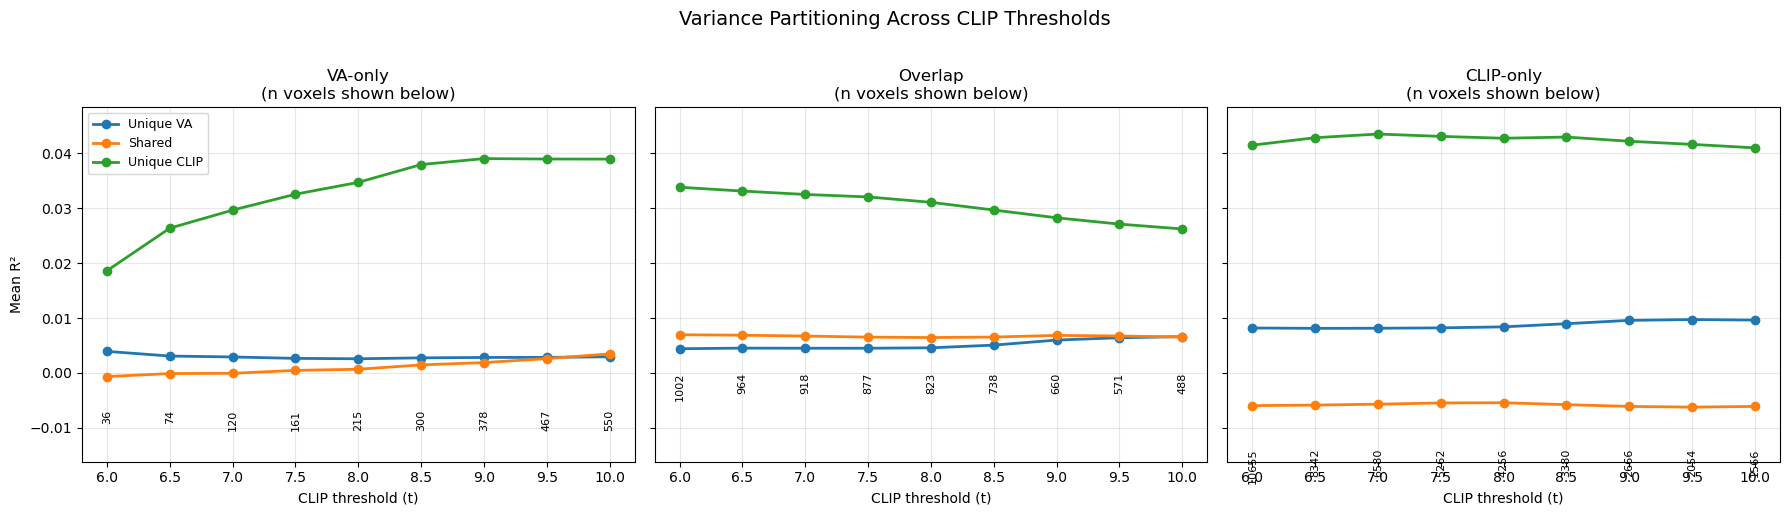

In [30]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

roi_order = ['VA-only', 'Overlap', 'CLIP-only']

for ax, roi in zip(axes, roi_order):

    tmp = results_df[results_df['ROI'] == roi].sort_values('threshold')

    ax.plot(
        tmp['threshold'],
        tmp['unique_VA'],
        '-o',
        linewidth=2,
        label='Unique VA'
    )

    ax.plot(
        tmp['threshold'],
        tmp['shared'],
        '-o',
        linewidth=2,
        label='Shared'
    )

    ax.plot(
        tmp['threshold'],
        tmp['unique_CLIP'],
        '-o',
        linewidth=2,
        label='Unique CLIP'
    )

    # ---------------------------------------
    # voxel counts underneath
    # ---------------------------------------

    ymin = min(
        tmp['unique_VA'].min(),
        tmp['shared'].min(),
        tmp['unique_CLIP'].min()
    )

    ymax = max(
        tmp['unique_VA'].max(),
        tmp['shared'].max(),
        tmp['unique_CLIP'].max()
    )

    yrange = ymax - ymin

    y_text = ymin - 0.15 * yrange

    for _, row in tmp.iterrows():

        ax.text(
            row['threshold'],
            y_text,
            f"{int(row['n_voxels'])}",
            ha='center',
            va='top',
            fontsize=8,
            rotation=90
        )

    ax.set_title(
        f"{roi}\n(n voxels shown below)"
    )

    ax.set_xlabel('CLIP threshold (t)')
    ax.grid(True, alpha=0.3)

    ax.set_xticks(np.arange(6, 10.1, 0.5))

    ax.set_ylim(
        y_text - 0.05 * yrange,
        ymax + 0.1 * yrange
    )

axes[0].set_ylabel('Mean R²')

axes[0].legend(
    loc='upper left',
    fontsize=9
)

plt.suptitle(
    'Variance Partitioning Across CLIP Thresholds',
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()